# Notebook 6: CI/CD and Automated Testing

### Objectives

This notebook documents the implementation of:

1. Reusable data-processing and model-training scripts
2. Unit testing with Pytest
3. Code-quality checking with Ruff
4. Automated model training
5. Continuous Integration using GitHub Actions
6. Workflow logs and generated artifacts

The purpose of automated testing is to verify that the data-processing
and machine-learning code continues to work correctly whenever the project
is modified.

The CI pipeline will automatically run whenever code is pushed to GitHub
or a pull request is created.

# Verify the project location

In [214]:
from pathlib import Path
import sys

# Detect the current location of the notebook.
current_directory = Path.cwd().resolve()

# The notebook is expected to be inside the notebooks folder.
if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

print("Current directory :", current_directory)
print("Project root      :", project_root)
print("Python version    :", sys.version)

Current directory : D:\MLOps\heart-disease-mlops\notebooks
Project root      : D:\MLOps\heart-disease-mlops
Python version    : 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


# Verify the important files

In [215]:
dataset_path = project_root / "data" / "processed" / "heart_cleaned.csv"
model_path = project_root / "models" / "heart_disease_pipeline.joblib"
requirements_path = project_root / "requirements.txt"

important_paths = {
    "Cleaned dataset": dataset_path,
    "Packaged model": model_path,
    "Requirements file": requirements_path,
}

for name, path in important_paths.items():
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{name:<20}: {status}")
    print(f"  Path: {path}")

Cleaned dataset     : FOUND
  Path: D:\MLOps\heart-disease-mlops\data\processed\heart_cleaned.csv
Packaged model      : FOUND
  Path: D:\MLOps\heart-disease-mlops\models\heart_disease_pipeline.joblib
Requirements file   : FOUND
  Path: D:\MLOps\heart-disease-mlops\requirements.txt


# Check the dataset

In [216]:
import pandas as pd

data = pd.read_csv(dataset_path)

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

print("\nTarget distribution:")
print(data["target"].value_counts().sort_index())

Dataset shape: (303, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


# Create Python package files
Testing the notebook itself would be difficult, so reusable operations will be moved into the src folder.
next is to make empty files with powershell

## Reusable Data-Processing Module

The main data-processing operations were moved into
`src/data_processing.py`.

This improves:

- Reusability
- Testability
- Maintainability
- CI/CD compatibility

The module validates the dataset, separates features and target,
and produces a reproducible stratified train-test split.

In [217]:
import sys

# Add the project root to Python's import path.
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_processing import (
    create_train_test_split,
    load_data,
    split_features_target,
)

# Run the data-processing functions

In [218]:
data = load_data(dataset_path)

X, y = split_features_target(data)

X_train, X_test, y_train, y_test = create_train_test_split(
    features=X,
    target=y,
    test_size=0.20,
    random_state=42,
)

print("Complete dataset shape :", data.shape)
print("Feature matrix shape   :", X.shape)
print("Target shape           :", y.shape)
print("Training features      :", X_train.shape)
print("Testing features       :", X_test.shape)
print("Training target        :", y_train.shape)
print("Testing target         :", y_test.shape)

Complete dataset shape : (303, 14)
Feature matrix shape   : (303, 13)
Target shape           : (303,)
Training features      : (242, 13)
Testing features       : (61, 13)
Training target        : (242,)
Testing target         : (61,)


# Check that the split is reproducible

In [219]:
X_train_2, X_test_2, y_train_2, y_test_2 = create_train_test_split(
    features=X,
    target=y,
    test_size=0.20,
    random_state=42,
)

print("Training features identical:", X_train.equals(X_train_2))
print("Testing features identical :", X_test.equals(X_test_2))
print("Training targets identical :", y_train.equals(y_train_2))
print("Testing targets identical  :", y_test.equals(y_test_2))

Training features identical: True
Testing features identical : True
Training targets identical : True
Testing targets identical  : True


# Write the test_data_processing.py File

# Configure Pytest, Rune the test, Below is the Output file image for referance
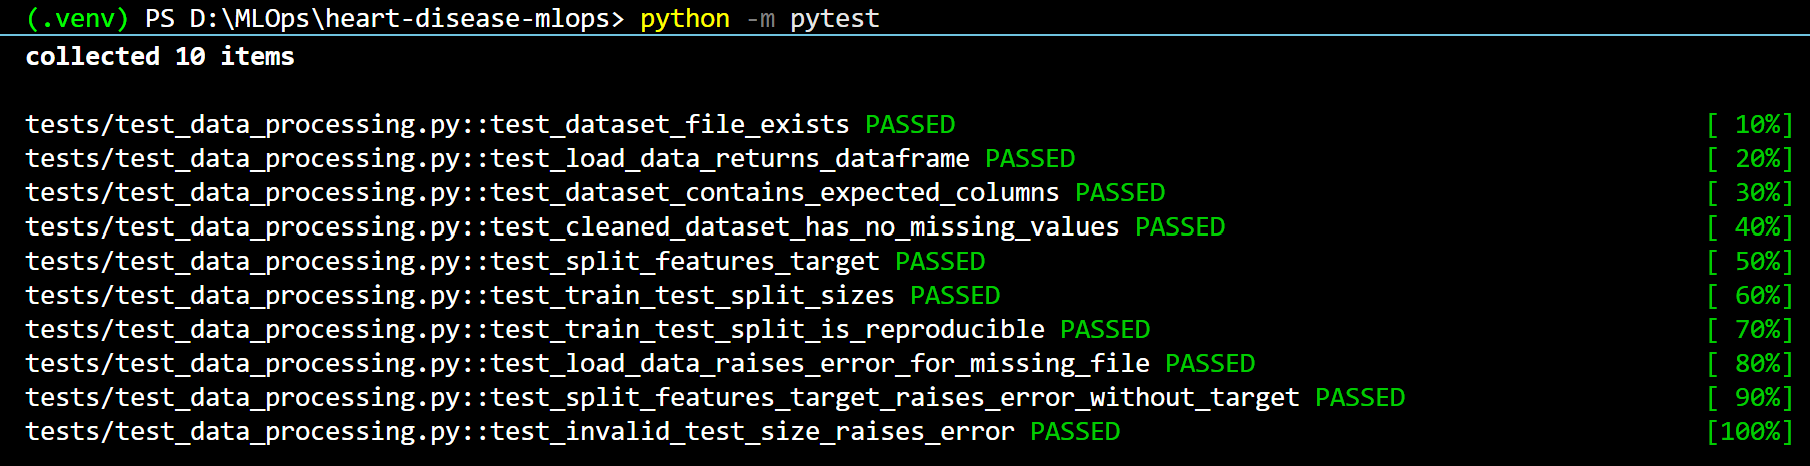

## Test Result

## Data-Processing Unit Test Results

The data-processing module was tested using Pytest.

The tests verify that:

1. The cleaned dataset exists.
2. The dataset loads as a Pandas DataFrame.
3. All expected columns are present.
4. The cleaned dataset has no missing values.
5. Features and target are separated correctly.
6. The train-test split has the expected dimensions.
7. The split is reproducible.
8. Missing files produce a clear error.
9. Missing target columns produce a clear error.
10. Invalid test sizes produce a clear error.

All tests passed successfully.

## Part 2: Model Training Script and Model Tests

Now it's time to make update in train.py file 

## Reusable Model-Training Module

The complete preprocessing and Random Forest model were moved into
`src/train.py`.

The module contains reusable functions for:

- Building the preprocessing and model pipeline
- Loading and splitting the data
- Training the model
- Evaluating accuracy and ROC-AUC
- Saving the trained model with Joblib

This allows the same training process to run locally, during testing,
and inside GitHub Actions.

In [220]:
from src.train import (
    build_model_pipeline,
    save_model,
    train_model,
)

# Train from Notebook 06

In [221]:
trained_pipeline, training_metrics = train_model(
    dataset_path
)

print("Training completed.")
print(
    f"Accuracy: {training_metrics['accuracy']:.4f}"
)
print(
    f"ROC-AUC : {training_metrics['roc_auc']:.4f}"
)

Training completed.
Accuracy: 0.9180
ROC-AUC : 0.9540


# Inspect the trained pipeline

In [222]:
print(trained_pipeline) 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
 

## Part 3: Ruff Linting and GitHub Actions
Refer Image Below

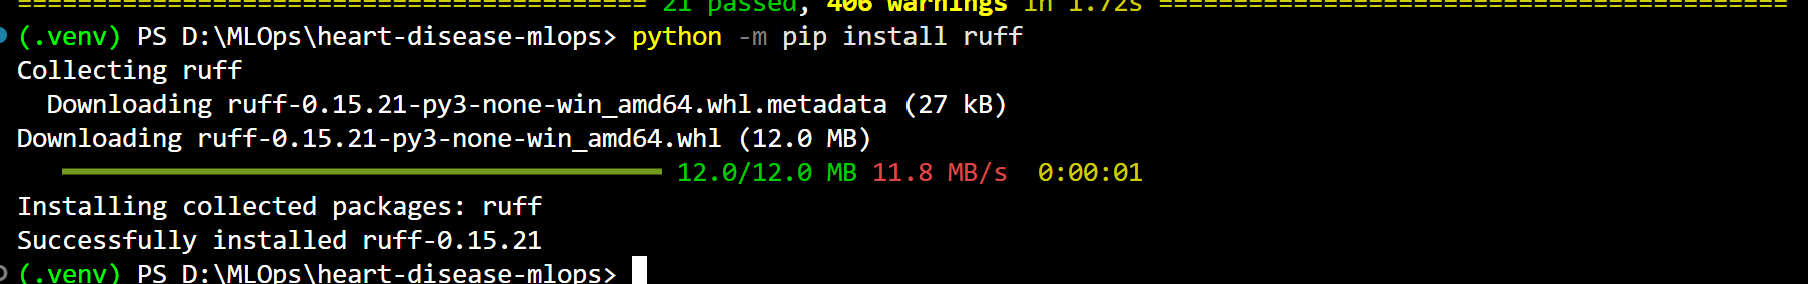

# Run Ruff on the project 

## Code Linting with Ruff

Ruff was added to perform automated code-quality checks.

Linting helps detect issues such as:

- Unused imports
- Undefined variables
- Incorrect import ordering
- Syntax and style problems

The following command was used:

```text
python -m ruff check src tests

Refer Image Below

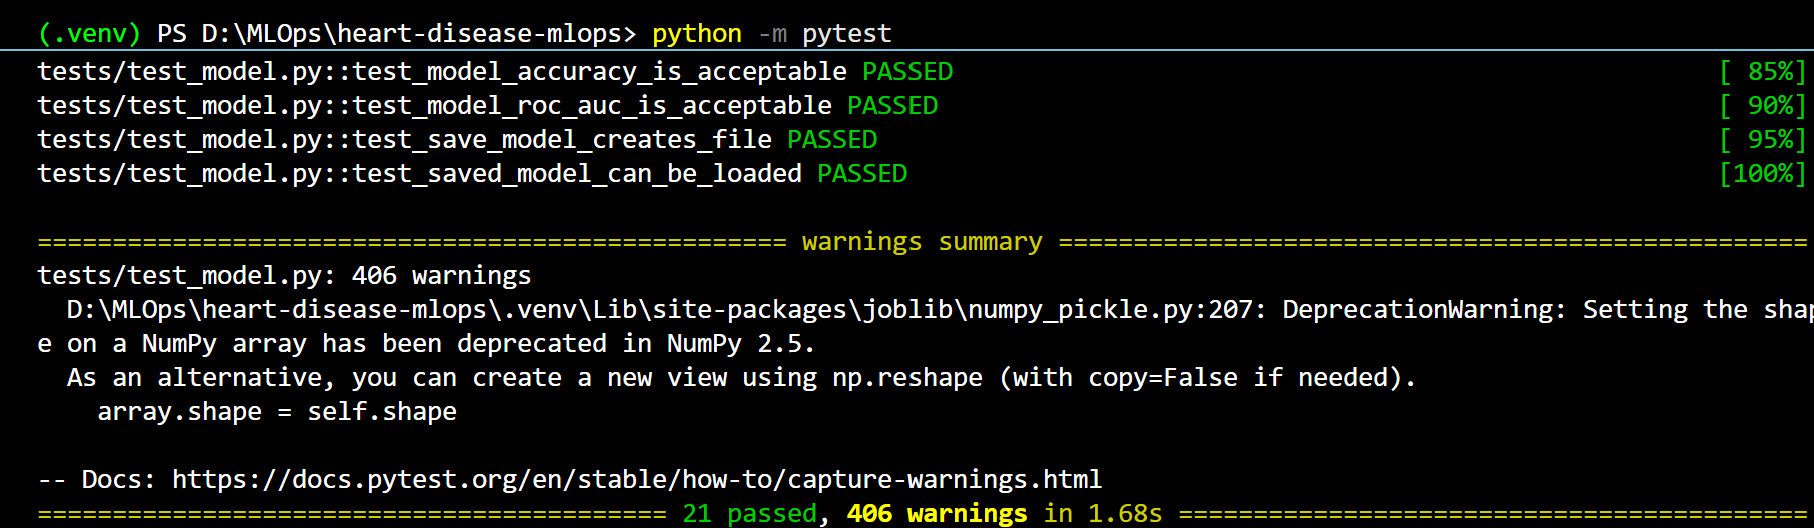